In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional visual style
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

# Define our key variables and foolproof colors (handling both numbers and text!)
churn_col = 'churn_next_60d'
custom_colors = {0: "#3498db", 1: "#e74c3c", "0": "#3498db", "1": "#e74c3c", 0.0: "#3498db", 1.0: "#e74c3c"} 

# Load the datasets
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
support_tickets = pd.read_csv('support_tickets.csv')
events = pd.read_csv('web_events_snapshot.csv')
labels = pd.read_csv('churn_labels.csv')

print("All datasets loaded successfully!")

All datasets loaded successfully!


##### Data Quality Audit

In [23]:
# Create a dictionary of our loaded datasets
data_dict = {
    "Customers": customers,
    "Orders": orders,
    "Support Tickets": support_tickets,
    "Web/App Events": events,
    "Churn Labels": labels
}

def robust_data_audit(df_dict):
    for name, df in df_dict.items():
        print(f"========== {name} Data Audit ==========")
        print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
        print(f"Duplicate Rows: {df.duplicated().sum()}")
        
        # Check for missing values
        missing_data = df.isnull().sum()
        missing_data = missing_data[missing_data > 0]
        
        if not missing_data.empty:
            print("Missing Values:")
            for col, count in missing_data.items():
                print(f"  - {col}: {count} missing ({round((count/len(df))*100, 2)}%)")
        else:
            print("Missing Values: None found!")
            
        print("-" * 50 + "\n")

# Run the audit function
robust_data_audit(data_dict)

========== Customers Data Audit ==========
Total Rows: 2400 | Total Columns: 9
Duplicate Rows: 0
Missing Values:
  - loyalty_tier: 1386 missing (57.75%)
  - skin_type: 401 missing (16.71%)
--------------------------------------------------

========== Orders Data Audit ==========
Total Rows: 10009 | Total Columns: 10
Duplicate Rows: 0
Missing Values:
  - rating: 80 missing (0.8%)
--------------------------------------------------

========== Support Tickets Data Audit ==========
Total Rows: 1921 | Total Columns: 8
Duplicate Rows: 0
Missing Values: None found!
--------------------------------------------------

========== Web/App Events Data Audit ==========
Total Rows: 2400 | Total Columns: 10
Duplicate Rows: 0
Missing Values: None found!
--------------------------------------------------

========== Churn Labels Data Audit ==========
Total Rows: 2400 | Total Columns: 4
Duplicate Rows: 0
Missing Values: None found!
--------------------------------------------------



##### Joins & Base Data Preparation

In [24]:
# Base merge: Customers + Churn Labels using customer_id
df_eda = pd.merge(customers, labels, on='customer_id', how='left')

print(f"Data merged successfully! Total customers: {df_eda.shape[0]}")

Data merged successfully! Total customers: 2400


##### Chart 1 - Overall Churn Distribution

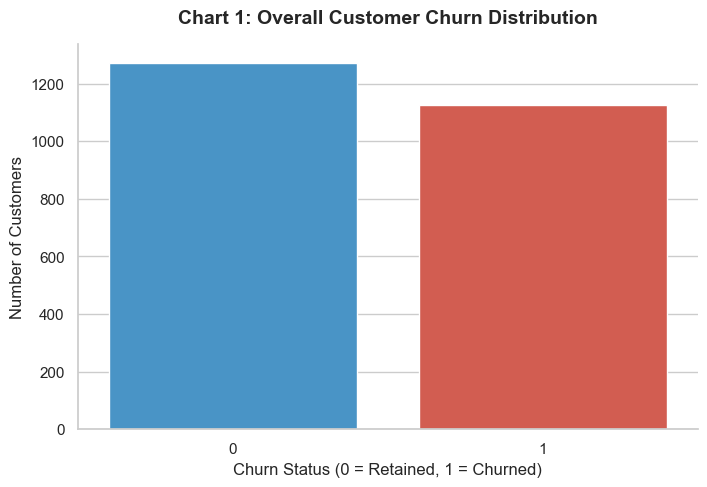

In [25]:
plt.figure(figsize=(8, 5))
# Added hue and legend=False to fix the Seaborn warning!
sns.countplot(data=df_eda, x=churn_col, hue=churn_col, palette=custom_colors, legend=False)
plt.title('Chart 1: Overall Customer Churn Distribution', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

##### Chart 2 - Demographics (Skin Type)

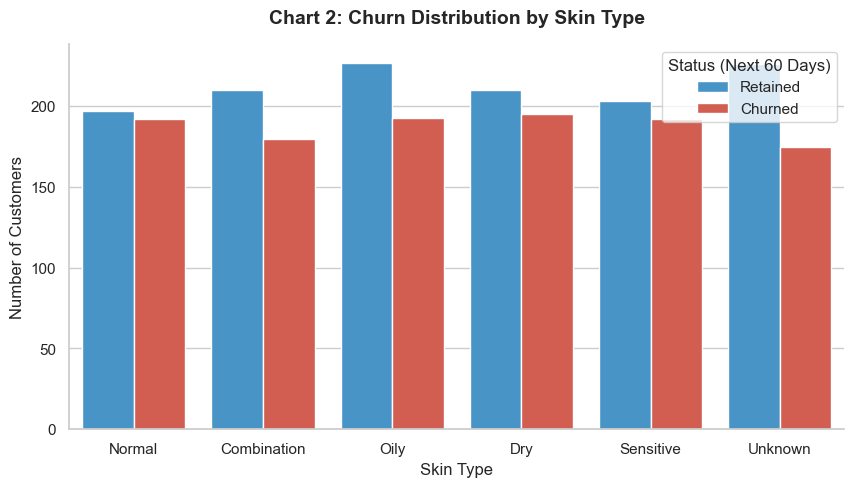

In [26]:
# Handle missing data by categorizing as 'Unknown'
df_eda['skin_type_filled'] = df_eda['skin_type'].fillna('Unknown')

plt.figure(figsize=(10, 5))
sns.countplot(data=df_eda, x='skin_type_filled', hue=churn_col, palette=custom_colors)
plt.title('Chart 2: Churn Distribution by Skin Type', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Skin Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, title='Status (Next 60 Days)', loc='upper right', labels=['Retained', 'Churned'])
plt.show()

##### Chart 3 - Demographics (Loyalty Tier)

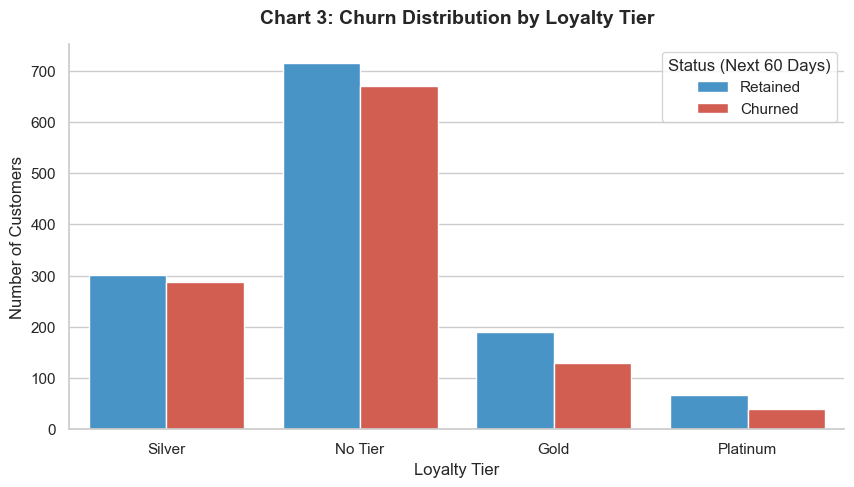

In [27]:
# Handle missing data by categorizing as 'No Tier'
df_eda['loyalty_tier_filled'] = df_eda['loyalty_tier'].fillna('No Tier')

plt.figure(figsize=(10, 5))
sns.countplot(data=df_eda, x='loyalty_tier_filled', hue=churn_col, palette=custom_colors)
plt.title('Chart 3: Churn Distribution by Loyalty Tier', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Loyalty Tier', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, title='Status (Next 60 Days)', loc='upper right', labels=['Retained', 'Churned'])
plt.show()

##### Chart 4 - Support Tickets vs. Churn

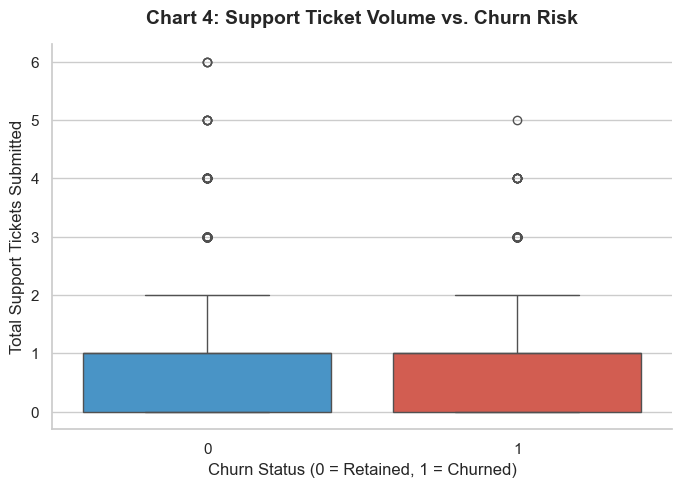

In [31]:
# Calculate total tickets per customer and merge
ticket_counts = support_tickets.groupby('customer_id').size().reset_index(name='ticket_count')

if 'ticket_count' in df_eda.columns: 
    df_eda = df_eda.drop(columns=['ticket_count'])
    
df_eda = pd.merge(df_eda, ticket_counts, on='customer_id', how='left')
df_eda['ticket_count'] = df_eda['ticket_count'].fillna(0) # Fill users with 0 tickets

plt.figure(figsize=(8, 5))
# Added hue=churn_col and legend=False to fix the Seaborn warning
sns.boxplot(data=df_eda, x=churn_col, y='ticket_count', hue=churn_col, palette=custom_colors, legend=False)
plt.title('Chart 4: Support Ticket Volume vs. Churn Risk', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)', fontsize=12)
plt.ylabel('Total Support Tickets Submitted', fontsize=12)
plt.show()

##### Chart 5 - Order Frequency vs. Churn

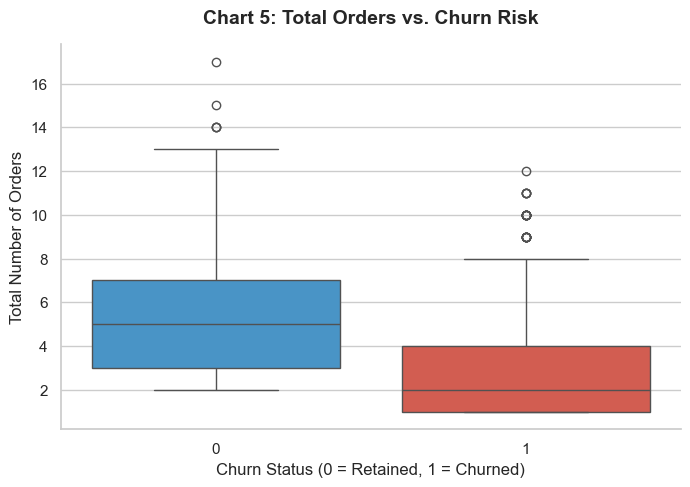

In [32]:
# Calculate total orders per customer and merge
order_counts = orders.groupby('customer_id').size().reset_index(name='total_orders')

if 'total_orders' in df_eda.columns: 
    df_eda = df_eda.drop(columns=['total_orders'])
    
df_eda = pd.merge(df_eda, order_counts, on='customer_id', how='left')
df_eda['total_orders'] = df_eda['total_orders'].fillna(0)

plt.figure(figsize=(8, 5))
# Added hue=churn_col and legend=False to fix the Seaborn warning
sns.boxplot(data=df_eda, x=churn_col, y='total_orders', hue=churn_col, palette=custom_colors, legend=False)
plt.title('Chart 5: Total Orders vs. Churn Risk', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)', fontsize=12)
plt.ylabel('Total Number of Orders', fontsize=12)
plt.show()

##### Chart 6 - Web/App Engagement vs. Churn

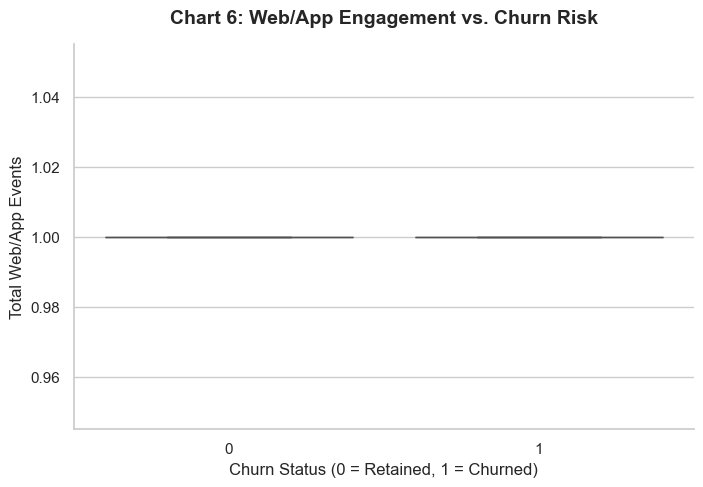

In [33]:
# Calculate total web/app events per customer and merge
event_counts = events.groupby('customer_id').size().reset_index(name='total_events')

if 'total_events' in df_eda.columns: 
    df_eda = df_eda.drop(columns=['total_events'])
    
df_eda = pd.merge(df_eda, event_counts, on='customer_id', how='left')
df_eda['total_events'] = df_eda['total_events'].fillna(0)

plt.figure(figsize=(8, 5))
# Added hue=churn_col and legend=False to fix the Seaborn warning
sns.boxplot(data=df_eda, x=churn_col, y='total_events', hue=churn_col, palette=custom_colors, legend=False)
plt.title('Chart 6: Web/App Engagement vs. Churn Risk', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)', fontsize=12)
plt.ylabel('Total Web/App Events', fontsize=12)
plt.show()